In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Libraries Imported")

Libraries Imported


In [ ]:
data = pd.read_csv('cardata.csv')
print("Dataset reading complete")

Dataset reading complete


In [ ]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [ ]:
data.shape

(301, 9)

In [ ]:
# Count occurrences of each Fuel_Type in the dataset
data['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


In [ ]:
# Count occurrences of each Seller_Type in the dataset
data['Seller_Type'].value_counts()

,count
Seller_Type,
Dealer,195
Individual,106


In [ ]:
#Count occurrences of each Transmission type in the dataset
data['Transmission'].value_counts()

,count
Transmission,
Manual,261
Automatic,40


In [ ]:
data.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Owner', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol',
       'Seller_Type_Individual', 'Transmission_Manual'],
      dtype='object')

In [ ]:
# Create feature matrix X by dropping Car_Name and Selling_Price columns
X = data.drop(['Car_Name','Selling_Price'], axis=1)
print("Feature matrix X created by dropping 'Car_Name' and 'Selling_Price' columns.")

Feature matrix X created by dropping 'Car_Name' and 'Selling_Price' columns.


In [ ]:
# Create target vector Y containing the Selling_Price column
Y = data['Selling_Price']
print("Target vector Y created from 'Selling_Price' column.")

Target vector Y created from 'Selling_Price' column.


In [ ]:
X.head()

,Year,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,5.59,27000,0,0,1,0,1
1,2013,9.54,43000,0,1,0,0,1
2,2017,9.85,6900,0,0,1,0,1
3,2011,4.15,5200,0,0,1,0,1
4,2014,6.87,42450,0,1,0,0,1


In [ ]:
Y.head()

,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60


In [ ]:
# Split the dataset into training and testing sets, then train a Linear Regression model
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.20, random_state = 42)
print("Dataset split into training and testing sets")

Dataset split into training and testing sets


In [ ]:
#create the model
model = LinearRegression()
print("Model Created")

Model Created


In [ ]:
#train the model
model.fit(X_train, Y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
# Generate predictions for training and testing datasets using the trained model
Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)
print("Predictions generated for both Train and Test sets.")

Predictions generated for both Train and Test sets.


In [ ]:
# Evaluate model performance on training data using MAE, MSE, RMSE, and R2 score
mae = mean_absolute_error(Y_train, Y_train_pred)
mse = mean_squared_error(Y_train, Y_train_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_train, Y_train_pred)
print("Model Performance on Training Data:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2) Score:", r2)

Model Performance on Training Data:
Mean Absolute Error (MAE): 1.1675804448346956
Mean Squared Error (MSE): 2.9437205399629773
Root Mean Squared Error (RMSE): 1.7157274084081588
R-squared (R2) Score: 0.8886517300804573


In [ ]:
# Evaluate model performance on testing data using MAE, MSE, RMSE, and R2 score
mae = mean_absolute_error(Y_test, Y_test_pred)
mse = mean_squared_error(Y_test, Y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_test_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 1.2162256821298496
Mean Squared Error (MSE): 3.478803970641293
Root MSE (RMSE): 1.8651552135522913
R2 Score: 0.8489813024897594


In [ ]:
# Retrieve the learned coefficients and intercept of the linear regression model
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 3.53801365e-01  4.29152503e-01 -6.15725866e-06 -9.03759824e-01
  2.53327258e+00  7.38464226e-01 -1.19059291e+00 -1.63902155e+00]
Intercept: -709.9529230448213


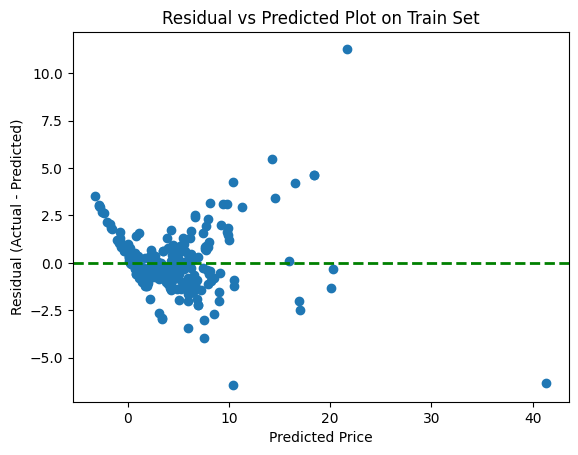

In [ ]:
# Plot residuals against predicted values on training data to analyze error patterns
residuals = Y_train - Y_train_pred
plt.scatter(Y_train_pred, residuals)
plt.axhline(0, color='green', linestyle='--', linewidth=2)
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual vs Predicted Plot on Train Set")
plt.show()